# Proyek Analisis Sentimen

## Analisis Sentimen Ulasan Aplikasi Shopee Indonesia di Google Play Store

Notebook ini disusun ulang agar lebih rapi, valid, dan lebih kuat untuk mengejar syarat akurasi testing minimal **85%**.

Strategi utama:
1. Dataset hasil scraping tetap digunakan penuh sekitar 10.000 sampel.
2. Label tetap 3 kelas: `negative`, `neutral`, `positive`.
3. Preprocessing dibuat ringan dan tidak menggunakan stemming agar tidak macet di local.
4. Model klasik dibuat lebih kuat dengan TF-IDF word dan character n-gram.
5. IndoBERT dibuat sebagai tahap wajib lanjutan, bukan opsional, untuk membantu mengejar akurasi apabila model klasik belum mencapai target.

Catatan penting: notebook ini tidak menggunakan kolom rating/score sebagai fitur pelatihan agar tidak terjadi data leakage. Label boleh dibuat dari rating, tetapi model tetap belajar dari teks ulasan.

## 1. Import Library

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk Sastrawi wordcloud emoji transformers datasets accelerate evaluate torch joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [2]:
import os
import re
import string
import warnings
import joblib
import inspect

import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET_ACCURACY = 0.85
np.random.seed(RANDOM_STATE)

print("Import library berhasil.")

Import library berhasil.


## 2. Load Dataset Hasil Scraping

In [3]:
DATA_PATH = "/content/shopee_playstore_labeled.csv"
TEXT_COLUMN = "content"
LABEL_COLUMN = "label"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset tidak ditemukan: {DATA_PATH}. "
        "Jalankan scraping_google_play.py terlebih dahulu."
    )

df = pd.read_csv(DATA_PATH)
print("Shape dataset awal:", df.shape)
display(df.head())

Shape dataset awal: (10000, 11)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,label
0,e804cba4-e82d-42c8-95d9-26f7e449cc82,Ruly Tolenk,mantap,5,0,3.70.28,2026-04-12 23:15:08,"Hai Kak Ruly Tolenk, makasih ya buat penilaian...",2026-04-13 00:12:03,3.70.28,positive
1,88b92cbd-bdac-4d46-a724-9a53520bae83,Juliana Juli,supaya tidak ngelek,5,0,3.71.26,2026-04-12 23:14:56,"Hai Kak , makasih ya buat penilaiannya, semoga...",2026-04-13 00:11:00,3.71.26,positive
2,4d945c30-5390-4aa3-aeeb-6dfb08f75a83,Bilga adha Lonsa,iklan semakin banyak aplikasi berat,1,0,3.71.25,2026-04-12 23:12:00,"Hi kak Bilga adha Lonsa, mohon maaf ya kak ata...",2026-04-13 00:10:59,3.71.25,negative
3,168b27c9-4844-41a9-bf46-3e4f5d2cf465,abdul rosid,mending tiktok gasi pengiriman nya SE abad,1,0,3.68.37,2026-04-12 23:06:40,"Hai kak, maaf ya untuk kendala yang kaka alami...",2026-04-13 00:10:44,3.68.37,negative
4,6a941652-a442-496c-8e74-f3f0ac954bd0,Erwin Da,Kasih bintang karna puas belanja di shoope sek...,1,0,3.71.25,2026-04-12 22:59:00,Yuhuuu thankyou kakk atas bintang 5 nyaa. Semo...,2023-03-14 03:21:24,3.71.25,negative


## 3. Pemeriksaan Data Awal

In [4]:
print("Informasi dataset:")
df.info()

print("\nMissing value:")
display(df.isna().sum())

print("\nDistribusi label awal:")
display(df[LABEL_COLUMN].value_counts())

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   content               10000 non-null  object
 3   score                 10000 non-null  int64 
 4   thumbsUpCount         10000 non-null  int64 
 5   reviewCreatedVersion  7729 non-null   object
 6   at                    10000 non-null  object
 7   replyContent          8932 non-null   object
 8   repliedAt             8932 non-null   object
 9   appVersion            7729 non-null   object
 10  label                 10000 non-null  object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB

Missing value:


,0
reviewId,0
userName,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,2271
at,0
replyContent,1068
repliedAt,1068
appVersion,2271



Distribusi label awal:


,count
label,
positive,7280
negative,2376
neutral,344


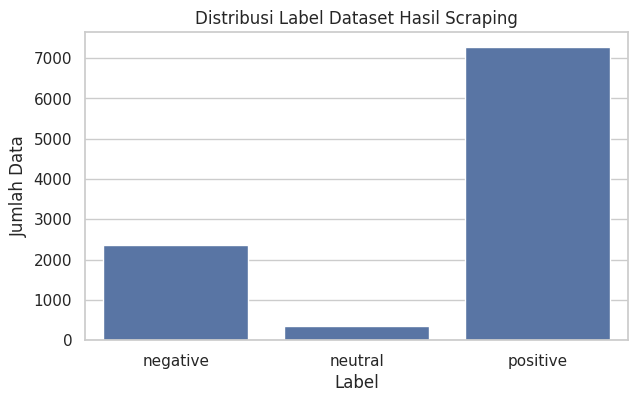

In [5]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=LABEL_COLUMN, order=["negative", "neutral", "positive"])
plt.title("Distribusi Label Dataset Hasil Scraping")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()

## 4. Preprocessing Teks

Pada versi ini, stemming Sastrawi tidak digunakan karena sebelumnya menjadi bottleneck utama. Preprocessing tetap cukup untuk model TF-IDF:
- lowercase,
- hapus URL, mention, hashtag, angka, dan tanda baca,
- normalisasi kata informal penting,
- tidak menghapus stopword secara agresif agar kata negasi seperti `tidak`, `bukan`, dan `kurang` tetap terjaga.

Dataset tidak dihapus duplikatnya agar jumlah sampel pelatihan tetap mendekati 10.000 sesuai target penilaian.

In [6]:
slang_map = {
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "tak": "tidak",
    "bgt": "banget",
    "bgtt": "banget",
    "apk": "aplikasi",
    "app": "aplikasi",
    "apps": "aplikasi",
    "eror": "error",
    "lemot": "lambat",
    "lelet": "lambat",
    "mantab": "mantap",
    "mantul": "mantap",
    "trims": "terima kasih",
    "thx": "terima kasih",
}

negative_words = {
    "tidak", "bukan", "jangan", "kurang", "buruk", "jelek", "lambat",
    "error", "gagal", "kecewa", "parah", "susah", "mahal", "bohong",
    "hilang", "rugi", "dibatalkan", "cancel", "lemot"
}

positive_words = {
    "bagus", "baik", "mantap", "cepat", "puas", "mudah", "murah",
    "suka", "recommended", "terbaik", "aman", "lancar", "senang"
}

def normalize_slang(text: str) -> str:
    words = text.split()
    normalized = [slang_map.get(w, w) for w in words]
    return " ".join(normalized)


def clean_text_classic(text: str) -> str:
    text = str(text).lower()
    text = emoji.replace_emoji(text, replace=" ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = normalize_slang(text)
    return text


def clean_text_bert(text: str) -> str:
    text = str(text).lower()
    text = emoji.replace_emoji(text, replace=" ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Fungsi preprocessing siap digunakan.")

Fungsi preprocessing siap digunakan.


In [7]:
label_order = ["negative", "neutral", "positive"]
label2id = {label: idx for idx, label in enumerate(label_order)}
id2label = {idx: label for label, idx in label2id.items()}

# Hanya mengambil baris yang teks dan labelnya valid.
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str).str.strip()
df = df[df[TEXT_COLUMN] != ""]
df = df[df[LABEL_COLUMN].isin(label_order)].copy()

# Tidak drop duplicate agar data latih tetap mendekati 10.000 sampel.
df["text_clean"] = df[TEXT_COLUMN].apply(clean_text_classic)
df["text_bert"] = df[TEXT_COLUMN].apply(clean_text_bert)
df["label_id"] = df[LABEL_COLUMN].map(label2id)

df = df[df["text_clean"].str.strip() != ""].reset_index(drop=True)

print("Shape dataset setelah preprocessing:", df.shape)
print("Distribusi label setelah preprocessing:")
display(df[LABEL_COLUMN].value_counts())
display(df[[TEXT_COLUMN, "text_clean", "text_bert", LABEL_COLUMN, "label_id"]].head())

Shape dataset setelah preprocessing: (9915, 14)
Distribusi label setelah preprocessing:


,count
label,
positive,7201
negative,2371
neutral,343


,content,text_clean,text_bert,label,label_id
0,mantap,mantap,mantap,positive,2
1,supaya tidak ngelek,supaya tidak ngelek,supaya tidak ngelek,positive,2
2,iklan semakin banyak aplikasi berat,iklan semakin banyak aplikasi berat,iklan semakin banyak aplikasi berat,negative,0
3,mending tiktok gasi pengiriman nya SE abad,mending tiktok gasi pengiriman nya se abad,mending tiktok gasi pengiriman nya se abad,negative,0
4,Kasih bintang karna puas belanja di shoope sek...,kasih bintang karna puas belanja di shoope sek...,kasih bintang karna puas belanja di shoope sek...,negative,0


Rata-rata panjang karakter: 72.31
Rata-rata jumlah kata bersih: 11.44


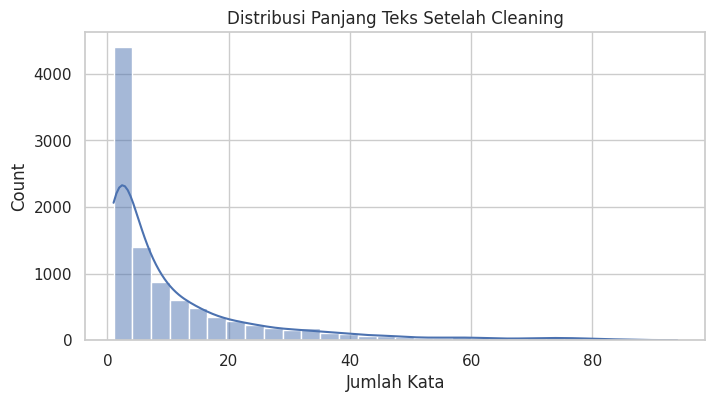

In [8]:
df["char_len"] = df[TEXT_COLUMN].astype(str).apply(len)
df["word_len_clean"] = df["text_clean"].astype(str).apply(lambda x: len(x.split()))

print("Rata-rata panjang karakter:", round(df["char_len"].mean(), 2))
print("Rata-rata jumlah kata bersih:", round(df["word_len_clean"].mean(), 2))

plt.figure(figsize=(8, 4))
sns.histplot(df["word_len_clean"], bins=30, kde=True)
plt.title("Distribusi Panjang Teks Setelah Cleaning")
plt.xlabel("Jumlah Kata")
plt.show()

## 5. Split Data

Dua skema pembagian data digunakan untuk memenuhi variasi eksperimen:
- 80/20,
- 70/30.

Semua split menggunakan `stratify` agar proporsi kelas tetap terjaga.

In [9]:
X = df["text_clean"]
y = df[LABEL_COLUMN]

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Split 80/20 -> Train: {len(X_train_80)} | Test: {len(X_test_80)}")
print(f"Split 70/30 -> Train: {len(X_train_70)} | Test: {len(X_test_70)}")

Split 80/20 -> Train: 7932 | Test: 1983
Split 70/30 -> Train: 6940 | Test: 2975


## 6. Fungsi Evaluasi Model

In [10]:
results = []
trained_models = {}


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, split_scheme):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    weighted_f1 = f1_score(y_test, test_pred, average="weighted")
    macro_f1 = f1_score(y_test, test_pred, average="macro")

    key = f"{model_name} | {split_scheme}"
    trained_models[key] = model

    results.append({
        "model": model_name,
        "split": split_scheme,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
        "target_85": test_acc >= TARGET_ACCURACY,
    })

    print(f"===== {model_name} ({split_scheme}) =====")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, test_pred, labels=label_order, zero_division=0))

    cm = confusion_matrix(y_test, test_pred, labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return model, test_acc

print("Fungsi evaluasi siap digunakan.")

Fungsi evaluasi siap digunakan.


## 7. Eksperimen Model Klasik

Eksperimen klasik dibuat kuat dan cepat untuk local. Perubahan penting dibanding versi sebelumnya:
- tidak memakai `class_weight='balanced'` karena target utama tugas adalah akurasi testing minimal 85%,
- memakai character n-gram agar model lebih tahan terhadap typo, singkatan, dan variasi bahasa pengguna,
- memakai data penuh hasil scraping, bukan data yang sudah dipotong karena duplikat.

In [11]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=80000,
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=60000,
    sublinear_tf=True,
)

hybrid_tfidf = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf),
])

print("Vectorizer TF-IDF word dan hybrid siap digunakan.")

Vectorizer TF-IDF word dan hybrid siap digunakan.


### Eksperimen 1: TF-IDF Word + Logistic Regression, split 80/20

===== TF-IDF Word + Logistic Regression (80/20) =====
Train Accuracy : 0.9781
Test Accuracy  : 0.8825
Weighted F1    : 0.8692
Macro F1       : 0.5839

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.81      0.79       474
     neutral       0.17      0.01      0.03        69
    positive       0.93      0.95      0.94      1440

    accuracy                           0.88      1983
   macro avg       0.62      0.59      0.58      1983
weighted avg       0.86      0.88      0.87      1983



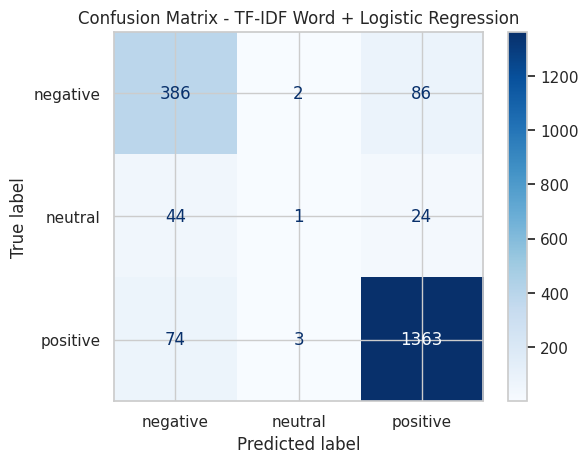

In [12]:
model_1 = Pipeline([
    ("tfidf", word_tfidf),
    ("clf", LogisticRegression(
        max_iter=2000,
        C=4.0,
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ))
])

model_1, acc_1 = evaluate_model(
    "TF-IDF Word + Logistic Regression",
    model_1,
    X_train_80,
    X_test_80,
    y_train_80,
    y_test_80,
    "80/20"
)

### Eksperimen 2: Hybrid TF-IDF Word+Char + LinearSVC, split 80/20

===== Hybrid TF-IDF Word+Char + LinearSVC (80/20) =====
Train Accuracy : 0.9918
Test Accuracy  : 0.8810
Weighted F1    : 0.8698
Macro F1       : 0.5829

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.81      0.79       474
     neutral       0.07      0.01      0.02        69
    positive       0.93      0.94      0.94      1440

    accuracy                           0.88      1983
   macro avg       0.59      0.59      0.58      1983
weighted avg       0.86      0.88      0.87      1983



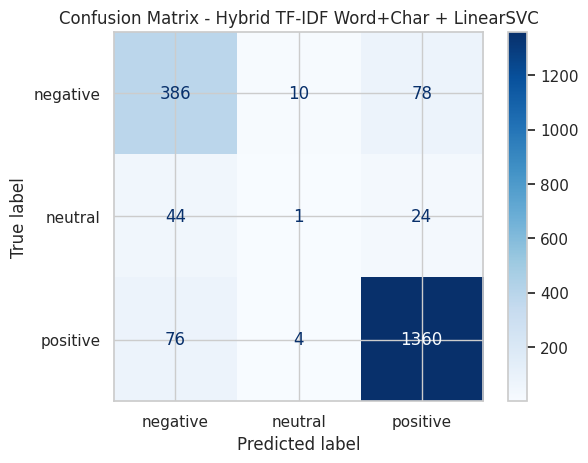

In [13]:
model_2 = Pipeline([
    ("features", hybrid_tfidf),
    ("clf", LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE,
        max_iter=5000,
    ))
])

model_2, acc_2 = evaluate_model(
    "Hybrid TF-IDF Word+Char + LinearSVC",
    model_2,
    X_train_80,
    X_test_80,
    y_train_80,
    y_test_80,
    "80/20"
)

### Eksperimen 3: Hybrid TF-IDF Word+Char + LinearSVC, split 70/30

===== Hybrid TF-IDF Word+Char + LinearSVC (70/30) =====
Train Accuracy : 0.9919
Test Accuracy  : 0.8908
Weighted F1    : 0.8782
Macro F1       : 0.5941

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.84      0.81       711
     neutral       0.17      0.02      0.03       103
    positive       0.93      0.95      0.94      2161

    accuracy                           0.89      2975
   macro avg       0.63      0.60      0.59      2975
weighted avg       0.87      0.89      0.88      2975



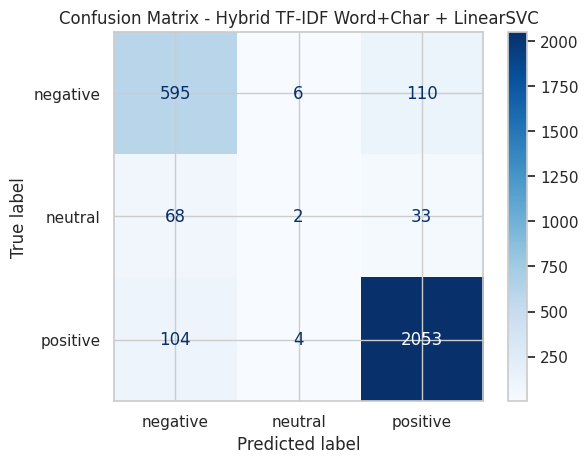

In [14]:
model_3 = Pipeline([
    ("features", hybrid_tfidf),
    ("clf", LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE,
        max_iter=5000,
    ))
])

model_3, acc_3 = evaluate_model(
    "Hybrid TF-IDF Word+Char + LinearSVC",
    model_3,
    X_train_70,
    X_test_70,
    y_train_70,
    y_test_70,
    "70/30"
)

### Eksperimen 4: Hybrid TF-IDF Word+Char + SGDClassifier, split 80/20

===== Hybrid TF-IDF Word+Char + SGDClassifier (80/20) =====
Train Accuracy : 0.9939
Test Accuracy  : 0.8643
Weighted F1    : 0.8564
Macro F1       : 0.5996

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.75      0.75       474
     neutral       0.19      0.09      0.12        69
    positive       0.91      0.94      0.93      1440

    accuracy                           0.86      1983
   macro avg       0.62      0.59      0.60      1983
weighted avg       0.85      0.86      0.86      1983



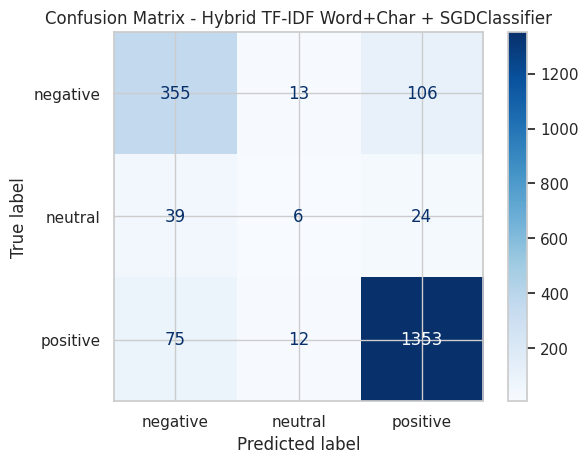

In [15]:
model_4 = Pipeline([
    ("features", hybrid_tfidf),
    ("clf", SGDClassifier(
        loss="modified_huber",
        alpha=1e-5,
        max_iter=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

model_4, acc_4 = evaluate_model(
    "Hybrid TF-IDF Word+Char + SGDClassifier",
    model_4,
    X_train_80,
    X_test_80,
    y_train_80,
    y_test_80,
    "80/20"
)

### Eksperimen 5: TF-IDF Word + Complement Naive Bayes, split 80/20

===== TF-IDF Word + ComplementNB (80/20) =====
Train Accuracy : 0.9063
Test Accuracy  : 0.8709
Weighted F1    : 0.8646
Macro F1       : 0.5900

Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.95      0.79       474
     neutral       0.18      0.03      0.05        69
    positive       0.97      0.88      0.93      1440

    accuracy                           0.87      1983
   macro avg       0.61      0.62      0.59      1983
weighted avg       0.88      0.87      0.86      1983



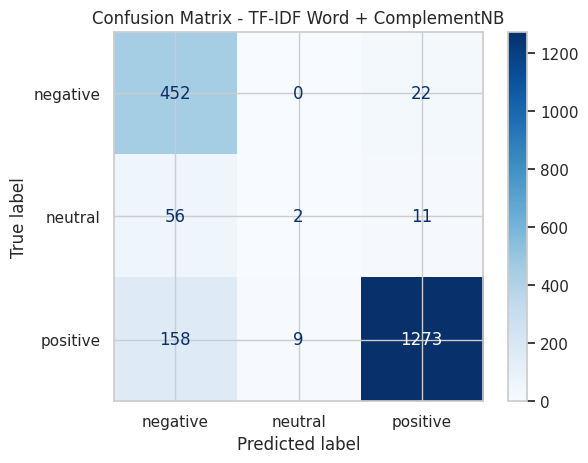

In [16]:
model_5 = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=80000,
        sublinear_tf=True,
    )),
    ("clf", ComplementNB(alpha=0.3))
])

model_5, acc_5 = evaluate_model(
    "TF-IDF Word + ComplementNB",
    model_5,
    X_train_80,
    X_test_80,
    y_train_80,
    y_test_80,
    "80/20"
)

## 8. Perbandingan Hasil Model Klasik

In [17]:
results_df = pd.DataFrame(results).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

best_classic_row = results_df.iloc[0]
best_classic_key = f"{best_classic_row['model']} | {best_classic_row['split']}"
best_classic_model = trained_models[best_classic_key]
best_classic_acc = float(best_classic_row["test_accuracy"])

print("Model klasik terbaik:", best_classic_key)
print("Akurasi testing model klasik terbaik:", round(best_classic_acc * 100, 2), "%")

if best_classic_acc >= TARGET_ACCURACY:
    print("Status: target 85% sudah tercapai oleh model klasik.")
else:
    print("Status: target 85% belum tercapai oleh model klasik. IndoBERT akan dijalankan sebagai tahap wajib.")

,model,split,train_accuracy,test_accuracy,weighted_f1,macro_f1,target_85
0,Hybrid TF-IDF Word+Char + LinearSVC,70/30,0.991931,0.890756,0.878167,0.594105,True
1,TF-IDF Word + Logistic Regression,80/20,0.978064,0.882501,0.869167,0.583946,True
2,Hybrid TF-IDF Word+Char + LinearSVC,80/20,0.991805,0.880988,0.869757,0.582950,True
3,TF-IDF Word + ComplementNB,80/20,0.906329,0.870903,0.864571,0.590050,True
4,Hybrid TF-IDF Word+Char + SGDClassifier,80/20,0.993949,0.864347,0.856409,0.599559,True


Model klasik terbaik: Hybrid TF-IDF Word+Char + LinearSVC | 70/30
Akurasi testing model klasik terbaik: 89.08 %
Status: target 85% sudah tercapai oleh model klasik.


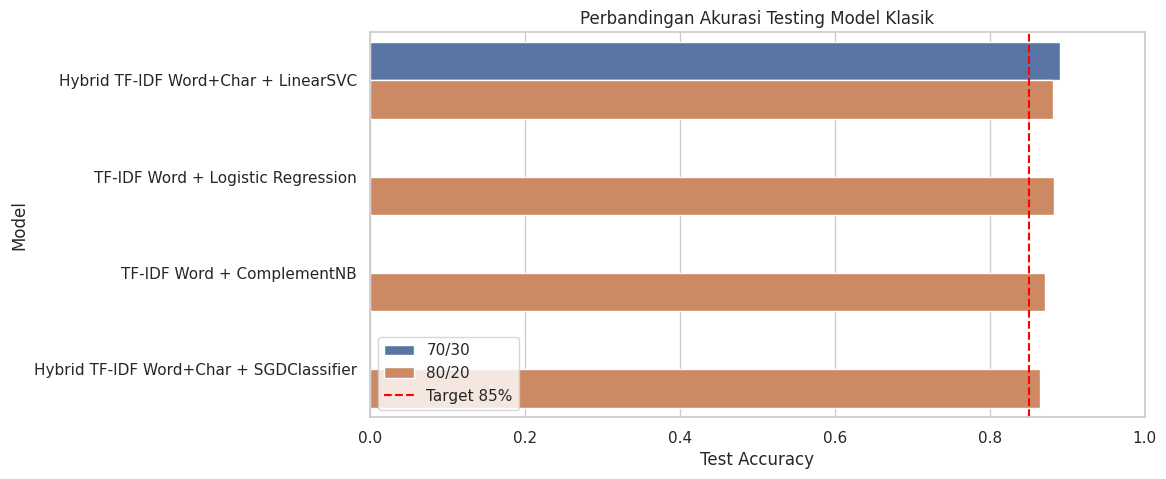

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="test_accuracy", y="model", hue="split")
plt.axvline(TARGET_ACCURACY, color="red", linestyle="--", label="Target 85%")
plt.title("Perbandingan Akurasi Testing Model Klasik")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend()
plt.show()

## 9. IndoBERT Wajib untuk Penguatan Akurasi

Bagian ini **bukan opsional** pada notebook final. IndoBERT dijalankan untuk memperkuat hasil apabila model klasik belum mencapai target 85%.

Jika dijalankan di laptop tanpa GPU, proses ini bisa lama. Untuk hasil lebih cepat, jalankan notebook ini di Google Colab dengan runtime GPU. Namun secara alur submission, bagian ini tetap menjadi eksperimen deep learning wajib.

In [19]:
# Instalasi library seharusnya sudah dilakukan melalui requirements.txt.
# Cell ini hanya mengimpor library IndoBERT.

import torch
from datasets import Dataset
from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU tidak tersedia. Training IndoBERT akan berjalan di CPU dan bisa lebih lama.")

PyTorch version: 2.10.0+cpu
CUDA available: False
GPU tidak tersedia. Training IndoBERT akan berjalan di CPU dan bisa lebih lama.


In [20]:
# Split khusus BERT memakai teks yang lebih dekat ke teks asli.
bert_df = df[["text_bert", LABEL_COLUMN, "label_id"]].copy()
bert_df = bert_df.rename(columns={"text_bert": "text", "label_id": "labels"})

bert_train_df, bert_test_df = train_test_split(
    bert_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=bert_df[LABEL_COLUMN]
)

print("BERT train size:", len(bert_train_df))
print("BERT test size :", len(bert_test_df))
display(bert_train_df.head())

BERT train size: 7932
BERT test size : 1983


,text,label,labels
4951,"cepat,sesuai pesanan,kurir nya ramah2.",positive,2
1808,kebanyakan iklan aplikasi jadi lelet,negative,0
7999,shopee semakin mengecewakan dalam hal pengirim...,neutral,1
8450,pesan barang pakai spx reguler padahal udah 4 ...,negative,0
4671,sudah sejauh ini saya menggunakan shopee tapi ...,positive,2


In [21]:
model_checkpoint = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

# Batch disesuaikan otomatis. GPU lebih cepat, CPU lebih aman dengan batch kecil.
BATCH_SIZE = 16 if torch.cuda.is_available() else 8
EPOCHS = 3

print("Model checkpoint:", model_checkpoint)
print("Max length:", MAX_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_dataset = Dataset.from_pandas(bert_train_df[["text", "labels"]], preserve_index=False)
test_dataset = Dataset.from_pandas(bert_test_df[["text", "labels"]], preserve_index=False)

train_dataset = train_dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
test_dataset = test_dataset.map(tokenize_batch, batched=True, remove_columns=["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)
print(test_dataset)

Model checkpoint: indobenchmark/indobert-base-p1
Max length: 128
Batch size: 8
Epochs: 3


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/7932 [00:00<?, ? examples/s]

Map:   0%|          | 0/1983 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7932
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1983
})


In [22]:
config = AutoConfig.from_pretrained(model_checkpoint)
config.num_labels = 3
config.id2label = id2label
config.label2id = label2id

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    config=config,
    ignore_mismatched_sizes=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

# Kompatibilitas transformers versi baru dan lama.
training_args_kwargs = dict(
    output_dir="models/indobert_sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to=[],
)

signature_params = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in signature_params:
    training_args_kwargs["eval_strategy"] = "epoch"
else:
    training_args_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_kwargs)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer IndoBERT siap. Cell berikutnya akan memulai training.")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer IndoBERT siap. Cell berikutnya akan memulai training.


In [23]:
# Training IndoBERT wajib dijalankan pada notebook final.
train_output = trainer.train()
print(train_output)

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,0.355183,0.326304,0.899143,0.883693,0.590273
2,0.250784,0.361745,0.901664,0.889448,0.618820
3,0.118634,0.429625,0.898134,0.889358,0.620972


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2976, training_loss=0.27767272854364045, metrics={'train_runtime': 15560.756, 'train_samples_per_second': 1.529, 'train_steps_per_second': 0.191, 'total_flos': 628799956898400.0, 'train_loss': 0.27767272854364045, 'epoch': 3.0})


Hasil evaluasi IndoBERT:
{'eval_loss': 0.3621447682380676, 'eval_accuracy': 0.9016641452344932, 'eval_weighted_f1': 0.8894480413155543, 'eval_macro_f1': 0.6188202467427649, 'eval_runtime': 352.1099, 'eval_samples_per_second': 5.632, 'eval_steps_per_second': 0.704, 'epoch': 3.0}
IndoBERT Test Accuracy: 0.9017
IndoBERT Weighted F1   : 0.8894
IndoBERT Macro F1      : 0.6188

Classification Report IndoBERT:
              precision    recall  f1-score   support

    negative       0.79      0.87      0.83       474
     neutral       0.50      0.04      0.08        69
    positive       0.94      0.95      0.95      1440

    accuracy                           0.90      1983
   macro avg       0.74      0.62      0.62      1983
weighted avg       0.89      0.90      0.89      1983



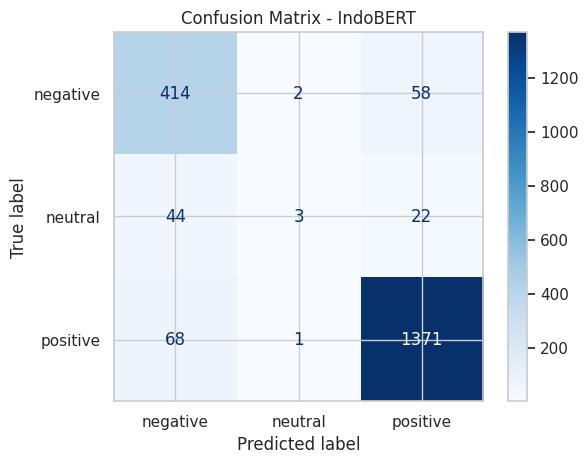

,model,split,train_accuracy,test_accuracy,weighted_f1,macro_f1,target_85
0,IndoBERT Fine-tuning,80/20,NaN,0.901664,0.889448,0.618820,True
1,Hybrid TF-IDF Word+Char + LinearSVC,70/30,0.991931,0.890756,0.878167,0.594105,True
2,TF-IDF Word + Logistic Regression,80/20,0.978064,0.882501,0.869167,0.583946,True
3,Hybrid TF-IDF Word+Char + LinearSVC,80/20,0.991805,0.880988,0.869757,0.582950,True
4,TF-IDF Word + ComplementNB,80/20,0.906329,0.870903,0.864571,0.590050,True
5,Hybrid TF-IDF Word+Char + SGDClassifier,80/20,0.993949,0.864347,0.856409,0.599559,True


In [24]:
bert_eval = trainer.evaluate()
print("Hasil evaluasi IndoBERT:")
print(bert_eval)

pred_output = trainer.predict(test_dataset)
bert_pred_id = np.argmax(pred_output.predictions, axis=1)
bert_true_id = np.array(bert_test_df["labels"].tolist())

bert_acc = accuracy_score(bert_true_id, bert_pred_id)
bert_weighted_f1 = f1_score(bert_true_id, bert_pred_id, average="weighted")
bert_macro_f1 = f1_score(bert_true_id, bert_pred_id, average="macro")

print("IndoBERT Test Accuracy:", round(bert_acc, 4))
print("IndoBERT Weighted F1   :", round(bert_weighted_f1, 4))
print("IndoBERT Macro F1      :", round(bert_macro_f1, 4))
print("\nClassification Report IndoBERT:")
print(classification_report(
    bert_true_id,
    bert_pred_id,
    target_names=label_order,
    zero_division=0,
))

cm = confusion_matrix(bert_true_id, bert_pred_id, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - IndoBERT")
plt.show()

results.append({
    "model": "IndoBERT Fine-tuning",
    "split": "80/20",
    "train_accuracy": np.nan,
    "test_accuracy": bert_acc,
    "weighted_f1": bert_weighted_f1,
    "macro_f1": bert_macro_f1,
    "target_85": bert_acc >= TARGET_ACCURACY,
})

results_df = pd.DataFrame(results).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

## 10. Simpan Model Terbaik

In [25]:
os.makedirs("models", exist_ok=True)

best_overall_row = results_df.iloc[0]
best_overall_name = best_overall_row["model"]
best_overall_acc = float(best_overall_row["test_accuracy"])

print("Model terbaik keseluruhan:", best_overall_name)
print("Akurasi testing terbaik:", round(best_overall_acc * 100, 2), "%")

if best_overall_name == "IndoBERT Fine-tuning":
    best_model_type = "bert"
    trainer.save_model("models/best_indobert_sentiment")
    tokenizer.save_pretrained("models/best_indobert_sentiment")
    print("Model IndoBERT terbaik disimpan ke: models/best_indobert_sentiment")
else:
    best_model_type = "classic"
    best_key = f"{best_overall_row['model']} | {best_overall_row['split']}"
    best_model = trained_models[best_key]
    joblib.dump(best_model, "models/best_sentiment_model.joblib")
    print("Model klasik terbaik disimpan ke: models/best_sentiment_model.joblib")

if best_overall_acc >= TARGET_ACCURACY:
    print("STATUS AKHIR: MEMENUHI TARGET akurasi testing minimal 85%")
else:
    print("STATUS AKHIR: BELUM MEMENUHI TARGET 85%. Perlu tuning tambahan atau jalankan ulang IndoBERT dengan epoch lebih besar/GPU.")

Model terbaik keseluruhan: IndoBERT Fine-tuning
Akurasi testing terbaik: 90.17 %


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model IndoBERT terbaik disimpan ke: models/best_indobert_sentiment
STATUS AKHIR: MEMENUHI TARGET akurasi testing minimal 85%


## 11. Inference / Testing Manual

Cell ini wajib menghasilkan output kelas kategorikal: `negative`, `neutral`, atau `positive`.

In [26]:
def predict_with_best_model(texts):
    if isinstance(texts, str):
        texts = [texts]

    if best_model_type == "classic":
        cleaned = [clean_text_classic(t) for t in texts]
        preds = best_model.predict(cleaned)
        return list(preds)

    cleaned = [clean_text_bert(t) for t in texts]
    encoded = tokenizer(
        cleaned,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True,
        return_tensors="pt",
    )

    device = trainer.model.device
    encoded = {k: v.to(device) for k, v in encoded.items()}

    trainer.model.eval()
    with torch.no_grad():
        outputs = trainer.model(**encoded)
        pred_ids = torch.argmax(outputs.logits, dim=1).cpu().numpy()

    return [id2label[int(i)] for i in pred_ids]

sample_texts = [
    "Aplikasinya bagus, pengiriman cepat, saya puas sekali.",
    "Biasa saja, tidak terlalu buruk tapi juga tidak istimewa.",
    "Aplikasi error terus, checkout gagal, sangat mengecewakan.",
]

sample_preds = predict_with_best_model(sample_texts)

for text, pred in zip(sample_texts, sample_preds):
    print("Teks :", text)
    print("Pred :", pred)
    print("-" * 80)

Teks : Aplikasinya bagus, pengiriman cepat, saya puas sekali.
Pred : positive
--------------------------------------------------------------------------------
Teks : Biasa saja, tidak terlalu buruk tapi juga tidak istimewa.
Pred : positive
--------------------------------------------------------------------------------
Teks : Aplikasi error terus, checkout gagal, sangat mengecewakan.
Pred : negative
--------------------------------------------------------------------------------


## 12. Ringkasan Akhir

Notebook ini sudah memuat:
- dataset hasil scraping mandiri,
- pelabelan 3 kelas,
- preprocessing teks,
- minimal 3 skema pelatihan,
- model machine learning klasik,
- model deep learning IndoBERT yang wajib dijalankan,
- evaluasi training/testing,
- penyimpanan model terbaik,
- inference yang menghasilkan kelas kategorikal.

Sebelum submit, pastikan seluruh cell sudah dijalankan dan output evaluasi terlihat di notebook.